In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Bundle Routing — Tutorial

`route_bundle` routes *N* start ports to *N* end ports, maintaining spacing and
avoiding obstacles.  This page covers parameters that are not shown in the
[Routing Overview](overview.py) or [Optical Routing Deep Dive](optical.py).

| Topic | API |
|---|---|
| Automatic port sorting | `sort_ports=True` |
| Per-bundle separation | `separation=` (DBU / µm) |
| S-bend compact routing | `sbend_factory=` |
| Bounding-box strategy | `bbox_routing='minimal'` / `'full'` |
| Obstacle avoidance | `bboxes=[...]`, `collision_check_layers=` |
| Mismatch tolerance | `allow_width_mismatch`, `allow_type_mismatch` |

## Setup

In [2]:
from functools import partial

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU
SEP = kf.kcl.to_dbu(2.0)  # 2 µm centre-to-centre extra separation

wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD_BND", sections=[(L.WGCLAD, 0, 2_000)])
)

bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5, radius=10, layer=L.WG, enclosure=wg_enc, angle=90
)
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)
bend_radius = kf.routing.optical.get_radius(bend90)

wl = kf.kcl.find_layer(L.WG)

## 1 · Port sorting — `sort_ports=True`

By default `route_bundle` pairs `start_ports[i]` with `end_ports[i]`.  If the two
lists are in opposite spatial orders (e.g., start ports run bottom-to-top while end
ports run top-to-bottom), routes will cross each other.

Setting `sort_ports=True` re-orders both lists by position so that the port closest
to the bottom on the start side connects to the port closest to the bottom on the
end side — eliminating crossings.

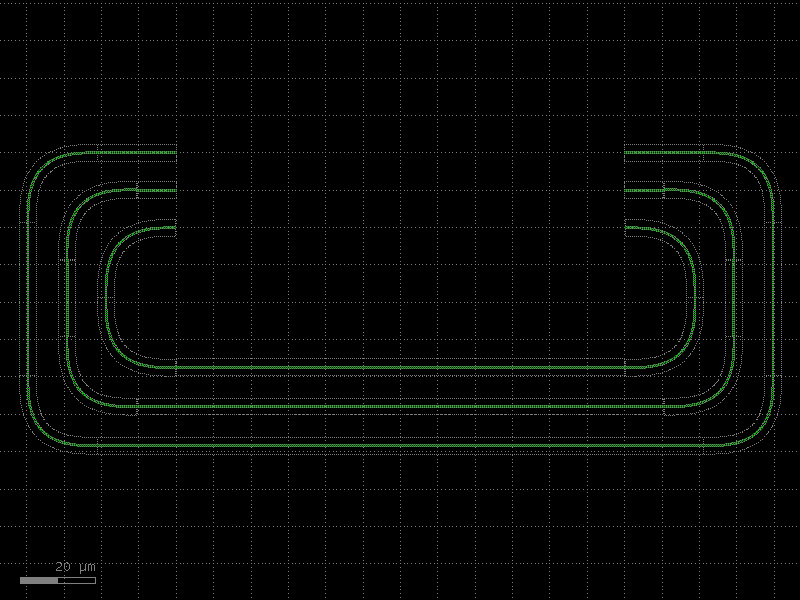

In [3]:
# Start ports are ordered top-to-bottom; end ports are ordered bottom-to-top.
# Without sort_ports the routes would cross.


@kf.cell
def bundle_sorted() -> kf.KCell:
    c = kf.KCell()

    start_ports = [
        c.create_port(
            name=f"in{i}",
            trans=kf.kdb.Trans(2, False, -60_000, (2 - i) * 10_000),  # reversed Y
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        for i in range(3)
    ]
    end_ports = [
        c.create_port(
            name=f"out{i}",
            trans=kf.kdb.Trans(0, False, 60_000, i * 10_000),  # normal Y
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        for i in range(3)
    ]

    # Use a wider local separation matching the 10µm port pitch — the
    # global SEP=2µm would require the router to bend each route to
    # compress the bundle, which collides with adjacent route bends.
    kf.routing.optical.route_bundle(
        c,
        start_ports=start_ports,
        end_ports=end_ports,
        separation=kf.kcl.to_dbu(10),
        straight_factory=straight_factory,
        bend90_cell=bend90,
        sort_ports=True,  # ← automatically matches by Y position
    )
    return c


c_sorted = bundle_sorted()
c_sorted.plot()

Without `sort_ports=True` the same port lists would produce three crossing routes.
Sorting resolves the crossing by pairing ports at the same relative position.

## 2 · Separation between routes

`separation` sets the **minimum centre-to-centre distance** between adjacent routes
in the bundle.  Increase it to open up more space between waveguides, for example
near dense arrays where cladding layers would otherwise overlap.

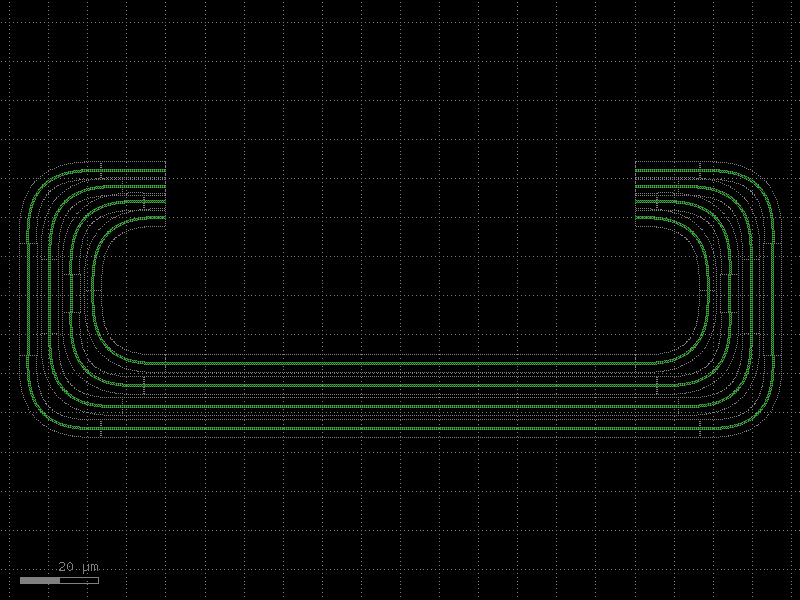

In [4]:
@kf.cell
def bundle_wide_sep() -> kf.KCell:
    c = kf.KCell()
    N = 4
    for i in range(N):
        c.create_port(
            name=f"in{i}",
            trans=kf.kdb.Trans(2, False, -60_000, i * 4_000),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        c.create_port(
            name=f"out{i}",
            trans=kf.kdb.Trans(0, False, 60_000, i * 4_000),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )

    kf.routing.optical.route_bundle(
        c,
        start_ports=list(c.ports.filter(port_type="optical", regex="^in")),
        end_ports=list(c.ports.filter(port_type="optical", regex="^out")),
        separation=kf.kcl.to_dbu(5.0),  # 5 µm — wider than the default 2 µm
        straight_factory=straight_factory,
        bend90_cell=bend90,
    )
    return c


bundle_wide_sep().plot()

## 3 · S-bend factory for compact fan-in / fan-out

When start and end ports face **each other** (e.g. East-facing starts and
West-facing ends) but their y-coordinates do not line up, a normal 90°-bend
router has to insert two right-angle bends per route — producing a large
vertical detour.  Passing an `sbend_factory` lets the router substitute a
compact Euler S-bend for the y mismatch instead.

The router calls the factory with `(c, offset, length, width)` and expects
back an `InstanceGroup` exposing ports `o1` (left) and `o2` (right).  The
example below wraps `kf.cells.euler.bend_s_euler` to match that protocol
and pads with a short straight if the requested `length` exceeds the
S-bend's own footprint.

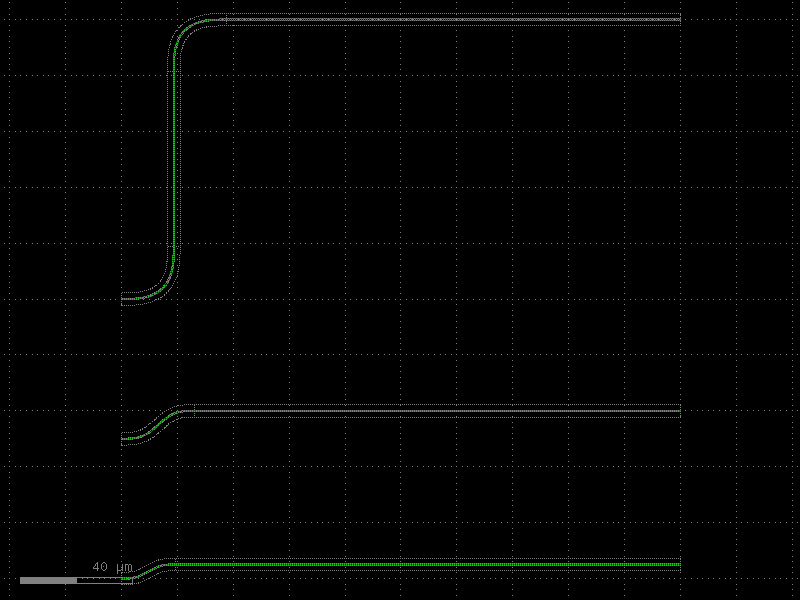

In [5]:
from typing import Any


def sbend_factory(
    c: kf.ProtoTKCell[Any],
    offset: int,
    length: int,
    width: int,
) -> kf.InstanceGroup:
    """SBendFactoryDBU wrapper around `bend_s_euler` + an optional straight."""
    ig = kf.InstanceGroup()

    sbend = c << kf.cells.euler.bend_s_euler(
        offset=c.kcl.to_um(offset),
        width=c.kcl.to_um(width),
        radius=10,
        layer=L.WG,
        enclosure=wg_enc,
    )
    ig.add(sbend)
    ig.add_port(name="o1", port=sbend.ports["o1"])

    pad = length - sbend.ibbox().width()
    if pad < 0:
        raise ValueError(
            f"sbend_factory: requested length={length} dbu is shorter than"
            f" the S-bend footprint ({sbend.ibbox().width()} dbu) for"
            f" offset={offset} dbu — no room for the S-bend."
        )
    if pad > 0:
        wg = c << straight_factory(width=width, length=pad)
        ig.add(wg)
        wg.connect("o1", sbend.ports["o2"])
        ig.add_port(name="o2", port=wg.ports["o2"])
    else:
        ig.add_port(name="o2", port=sbend.ports["o2"])

    return ig


@kf.cell
def bundle_sbend() -> kf.KCell:
    """Three routes with mismatched y on each side — forces S-bends."""
    c = kf.KCell()
    # Start ports face East (angle=0) at x=0.
    # End ports face West (angle=2) at x=200 µm.
    # Start and end y-coordinates differ by a few µm, so each route needs an
    # S-bend to bridge the y mismatch — that is what `sbend_factory` provides.
    start_y_um = [0, 50, 100]
    end_y_um = [5, 60, 200]

    start_ports = [
        c.create_port(
            name=f"in{i}",
            trans=kf.kdb.Trans(0, False, 0, kf.kcl.to_dbu(y)),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        for i, y in enumerate(start_y_um)
    ]
    end_ports = [
        c.create_port(
            name=f"out{i}",
            trans=kf.kdb.Trans(2, False, kf.kcl.to_dbu(200), kf.kcl.to_dbu(y)),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        for i, y in enumerate(end_y_um)
    ]

    kf.routing.optical.route_bundle(
        c,
        start_ports=start_ports,
        end_ports=end_ports,
        separation=SEP,
        straight_factory=straight_factory,
        bend90_cell=bend90,
        sbend_factory=sbend_factory,  # ← enables S-bend optimisation
    )
    return c


bundle_sbend().plot()

## 4 · Bounding-box routing strategy — `bbox_routing`

When obstacle boxes (`bboxes=`) are present the router must decide how far around
them to detour.

| Value | Behaviour |
|---|---|
| `'minimal'` (default) | Each route takes the shortest path around the obstacle. |
| `'full'` | All routes share a single bounding path — the bundle stays intact as it detours. |

`'full'` produces cleaner layouts when you want the bundle to remain grouped around
obstacles; `'minimal'` produces tighter total area when individual routes can fan
around obstacles independently.

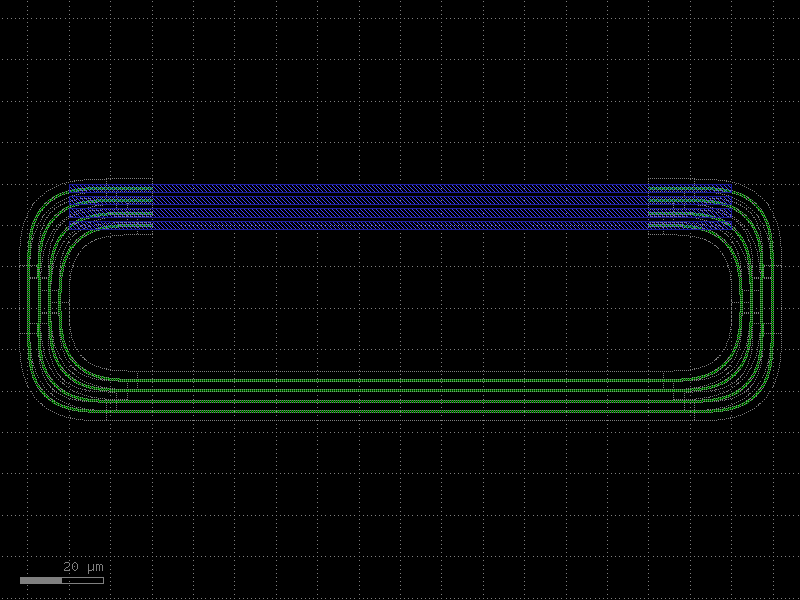

In [6]:
# Each route gets its own obstacle bbox.  An obstacle is treated as a
# keep-out region around the port(s) it contains: `route_smart` groups
# ports that fall *inside* the bbox and routes those routers as one bundle
# around it.  For that to engage, the bbox must extend past the port
# column on both sides by at least `bend_radius`:
# `xmin < ports.xmin - bend_radius` and `xmax > ports.xmax + bend_radius`.
#
# The y range of each bbox is kept narrower than the port pitch so each
# bbox only contains its own start and end port — adjacent routes' ports
# are excluded, demonstrating that `route_smart` can handle per-route
# obstacles independently.
N_BBOX = 4
PITCH_BBOX = 3_000
HALF_Y_BBOX = 1_000  # < PITCH/2 so the bbox excludes adjacent ports
blockers = [
    kf.kdb.Box(
        -80_000,
        i * PITCH_BBOX - HALF_Y_BBOX,
        80_000,
        i * PITCH_BBOX + HALF_Y_BBOX,
    )
    for i in range(N_BBOX)
]


@kf.cell
def bundle_bbox_minimal() -> kf.KCell:
    c = kf.KCell()
    for i in range(N_BBOX):
        c.create_port(
            name=f"in{i}",
            trans=kf.kdb.Trans(2, False, -60_000, i * PITCH_BBOX),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        c.create_port(
            name=f"out{i}",
            trans=kf.kdb.Trans(0, False, 60_000, i * PITCH_BBOX),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )

    # Draw each obstacle on the floorplan layer so they are visible alongside
    # the routed waveguides.
    for blocker in blockers:
        c.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(blocker)

    kf.routing.optical.route_bundle(
        c,
        start_ports=list(c.ports.filter(port_type="optical", regex="^in")),
        end_ports=list(c.ports.filter(port_type="optical", regex="^out")),
        separation=SEP,
        straight_factory=straight_factory,
        bend90_cell=bend90,
        bboxes=blockers,
        bbox_routing="minimal",
    )
    return c


@kf.cell
def bundle_bbox_full() -> kf.KCell:
    c = kf.KCell()
    for i in range(N_BBOX):
        c.create_port(
            name=f"in{i}",
            trans=kf.kdb.Trans(2, False, -60_000, i * PITCH_BBOX),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        c.create_port(
            name=f"out{i}",
            trans=kf.kdb.Trans(0, False, 60_000, i * PITCH_BBOX),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )

    for blocker in blockers:
        c.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(blocker)

    kf.routing.optical.route_bundle(
        c,
        start_ports=list(c.ports.filter(port_type="optical", regex="^in")),
        end_ports=list(c.ports.filter(port_type="optical", regex="^out")),
        separation=SEP,
        straight_factory=straight_factory,
        bend90_cell=bend90,
        bboxes=blockers,
        bbox_routing="full",
    )
    return c


bundle_bbox_minimal().plot()

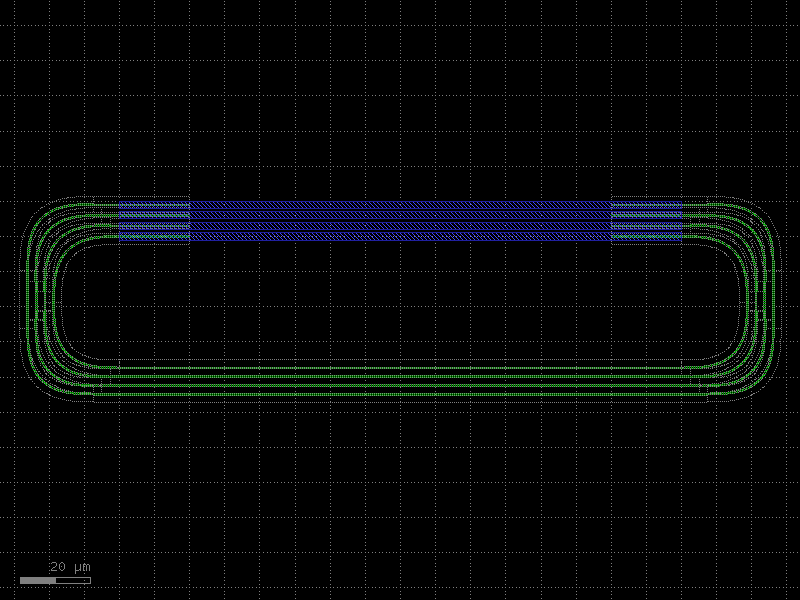

In [7]:
bundle_bbox_full().plot()

## 5 · Mismatch tolerance flags

`route_bundle` checks that paired ports share the same width, layer, and port type.
Relax individual checks when connecting different structures:

| Flag | Effect |
|---|---|
| `allow_width_mismatch=True` | Accept ports with different widths |
| `allow_layer_mismatch=True` | Accept ports on different layers |
| `allow_type_mismatch=True` | Accept ports with different `port_type` strings |

These flags do not insert tapers — the route simply uses the width/layer of the
first (start) port.  Insert explicit `taper_cell` for mode-converting transitions.

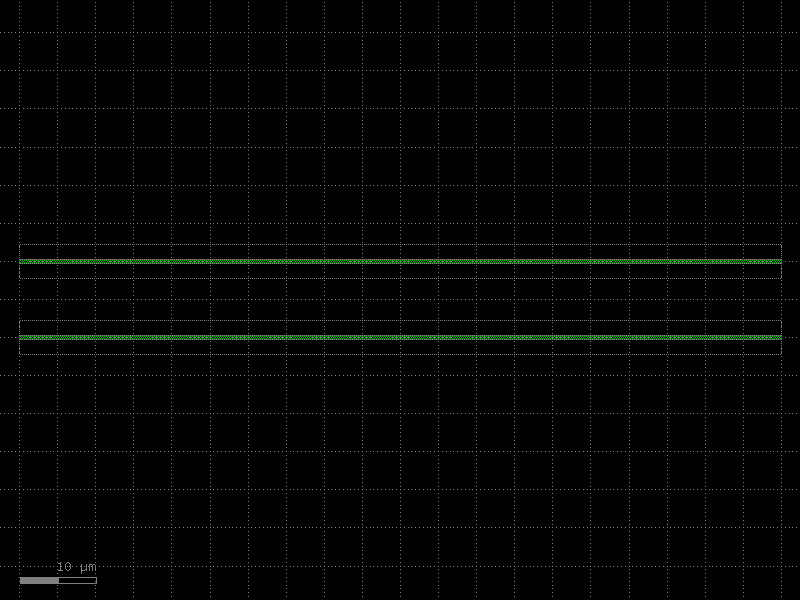

In [8]:
@kf.cell
def bundle_type_mismatch() -> kf.KCell:
    """Connect 'optical' start ports to 'pin' end ports."""
    c = kf.KCell()
    N = 2

    start_ports = [
        c.create_port(
            name=f"wg{i}",
            # East-facing start ports — routes will head east toward the end ports
            trans=kf.kdb.Trans(0, False, -50_000, i * 10_000),
            width=WG_WIDTH,
            layer=wl,
            port_type="optical",
        )
        for i in range(N)
    ]
    # End ports face West so the bundle goes straight across.  They also carry
    # a different `port_type` to exercise `allow_type_mismatch=True`.
    end_ports = [
        c.create_port(
            name=f"pin{i}",
            trans=kf.kdb.Trans(2, False, 50_000, i * 10_000),
            width=WG_WIDTH,
            layer=wl,
            port_type="pin",
        )
        for i in range(N)
    ]

    kf.routing.optical.route_bundle(
        c,
        start_ports=start_ports,
        end_ports=end_ports,
        separation=SEP,
        straight_factory=straight_factory,
        bend90_cell=bend90,
        allow_type_mismatch=True,  # ← suppress port_type equality check
    )
    return c


bundle_type_mismatch().plot()

## Parameter quick-reference

| Parameter | Type | Default | Notes |
|---|---|---|---|
| `separation` | DBU / µm | — | Min centre-to-centre spacing |
| `sort_ports` | `bool` | `False` | Sort both lists by position before pairing |
| `sbend_factory` | factory or `None` | `None` | Use S-bends for compact lateral shifts |
| `bbox_routing` | `'minimal'` / `'full'` | `'minimal'` | How the bundle detours around `bboxes` |
| `bboxes` | `list[kdb.Box]` | `None` | Physical obstacles to route around |
| `collision_check_layers` | `list[LayerInfo]` | `None` | Layers checked for geometric overlap |
| `on_collision` | `'error'` / `'show_error'` / `None` | `'show_error'` | Action on collision |
| `allow_width_mismatch` | `bool` | `None` | Skip width equality check |
| `allow_layer_mismatch` | `bool` | `None` | Skip layer equality check |
| `allow_type_mismatch` | `bool` | `None` | Skip port_type equality check |
| `route_width` | DBU / `list[DBU]` | `None` | Override wire width per route |
| `starts` / `ends` | DBU / steps | `None` | Entry/exit stub lengths (see [optical.py](optical.py)) |
| `waypoints` | `Trans` / `list[Point]` | `None` | Force routes through a point (see [optical.py](optical.py)) |
| `path_length_matching_config` | `PathLengthConfig` | `None` | Equal-length routing (see [optical.py](optical.py)) |

## See Also

| Topic | Where |
|-------|-------|
| Single-route optical options: waypoints, loopbacks, stubs | [Routing: Optical](optical.py) |
| Electrical bundle routing | [Routing: Electrical](electrical.py) |
| Equal path-length loops inside a bundle | [Routing: Path Length](path_length.py) |
| Manhattan backbone that bundle routing uses internally | [Routing: Manhattan](manhattan.py) |
| Routing overview and sub-module map | [Routing: Overview](overview.py) |
| Port sorting and orientation | [Core Concepts: Ports](../concepts/ports.py) |